# Task 4: Sentiment Analysis of E-Commerce Customer Reviews

## Objective

The objective of this task is to perform sentiment analysis on customer reviews from an e-commerce dataset.

Natural Language Processing (NLP) techniques are used to clean and process the review text. TextBlob is then used to calculate sentiment polarity and classify reviews into Positive, Negative, and Neutral categories.

The analysis helps identify overall customer sentiment and provides insights into customer feedback.

In [ ]:
!pip install -q nltk textblob wordcloud

## 1. Import Required Libraries

The following Python libraries are used for data manipulation, text preprocessing, sentiment analysis, and visualization.

In [ ]:
import pandas as pd
import nltk
import re
import matplotlib.pyplot as plt
from textblob import TextBlob
from wordcloud import WordCloud

## 2. Load the Dataset

The Olist Brazilian E-Commerce customer review dataset is loaded directly from the Olist public dataset repository.

In [ ]:
url = "https://raw.githubusercontent.com/olist/work-at-olist-data/master/datasets/olist_order_reviews_dataset.csv"

reviews = pd.read_csv(url)

print("Dataset shape:", reviews.shape)
reviews.head()

Dataset shape: (99224, 7)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## 3. Dataset Exploration

The dataset structure and missing values in the review text fields are examined before performing preprocessing.

In [ ]:
print(reviews.columns.tolist())

print("\nMissing values:")
print(reviews[["review_comment_title", "review_comment_message"]].isnull().sum())

['review_id', 'order_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_creation_date', 'review_answer_timestamp']

Missing values:
review_comment_title      87656
review_comment_message    58247
dtype: int64


## 4. Text Preprocessing

Customer review text is cleaned by handling missing values, converting text to lowercase, removing URLs and special characters, and eliminating unnecessary spaces.

In [ ]:
reviews["review_text"] = reviews["review_comment_message"].fillna("")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

reviews["clean_text"] = reviews["review_text"].apply(clean_text)

reviews[["review_text", "clean_text"]].head()

,review_text,clean_text
0,,
1,,
2,,
3,Recebi bem antes do prazo estipulado.,recebi bem antes do prazo estipulado
4,Parabéns lojas lannister adorei comprar pela I...,parabns lojas lannister adorei comprar pela in...


## 5. Remove Empty Reviews

Reviews with no meaningful text after preprocessing are removed so that only usable reviews are included in the sentiment analysis.

In [ ]:
reviews_clean = reviews[reviews["clean_text"].str.len() > 0].copy()

print("Reviews available for sentiment analysis:", len(reviews_clean))
reviews_clean[["clean_text", "review_score"]].head()

Reviews available for sentiment analysis: 40791


,clean_text,review_score
3,recebi bem antes do prazo estipulado,5
4,parabns lojas lannister adorei comprar pela in...,5
9,aparelho eficiente no site a marca do aparelho...,4
12,mas um pouco travandopelo valor ta boa,4
15,vendedor confivel produto ok e entrega antes d...,5


## 6. Sentiment Analysis

TextBlob is used to calculate the polarity of each review.

Based on the polarity score:
- Positive polarity → Positive sentiment
- Negative polarity → Negative sentiment
- Zero polarity → Neutral sentiment

In [ ]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

reviews_clean["sentiment"] = reviews_clean["clean_text"].apply(get_sentiment)

reviews_clean[["clean_text", "sentiment"]].head(10)

,clean_text,sentiment
3,recebi bem antes do prazo estipulado,Neutral
4,parabns lojas lannister adorei comprar pela in...,Neutral
9,aparelho eficiente no site a marca do aparelho...,Neutral
12,mas um pouco travandopelo valor ta boa,Neutral
15,vendedor confivel produto ok e entrega antes d...,Positive
16,gostaria de saber o que houve sempre recebi e ...,Neutral
19,pssimo,Neutral
22,loja nota,Neutral
24,obrigado pela atenao amim dispensada,Neutral
27,a compra foi realizada facilmente a entrega fo...,Neutral


In [ ]:
# ---------------------------------------------------------
# SENTIMENT DISTRIBUTION
# ---------------------------------------------------------
# Count the number of reviews belonging to each
# sentiment category.
# ---------------------------------------------------------

sentiment_counts = reviews_clean["sentiment"].value_counts()

print("Sentiment Distribution:")
print(sentiment_counts)

Sentiment Distribution:
sentiment
Neutral     37320
Positive     2973
Negative      498
Name: count, dtype: int64


## 7. Sentiment Distribution Visualization

The distribution of Positive, Negative, and Neutral reviews is visualized using a bar chart to make the overall customer sentiment easier to understand.

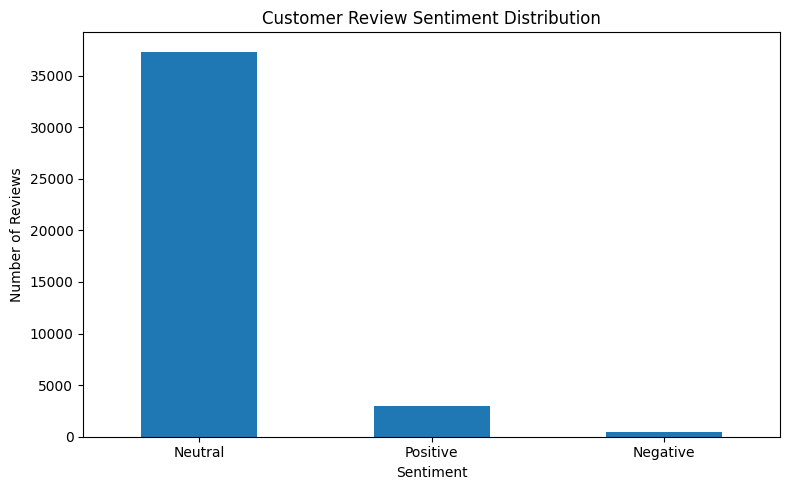

In [ ]:
# ---------------------------------------------------------
# SENTIMENT DISTRIBUTION BAR CHART
# ---------------------------------------------------------
# Create a bar chart showing the number of reviews
# in each sentiment category.
# ---------------------------------------------------------

plt.figure(figsize=(8, 5))

sentiment_counts.plot(
    kind="bar",
    title="Customer Review Sentiment Distribution"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Sentiment vs. Review Score

The sentiment classification is compared with the original customer review score to understand whether positive and negative textual sentiments are consistent with the numerical ratings.

In [ ]:
# ---------------------------------------------------------
# SENTIMENT VS. REVIEW SCORE
# ---------------------------------------------------------
# Calculate the average numerical review score (1–5)
# for each sentiment category.
# ---------------------------------------------------------

sentiment_score = (
    reviews_clean
    .groupby("sentiment")["review_score"]
    .mean()
    .sort_values(ascending=False)
)

print("Average Review Score by Sentiment:")
print(sentiment_score.round(2))

Average Review Score by Sentiment:
sentiment
Positive    4.39
Neutral     3.62
Negative    2.56
Name: review_score, dtype: float64


## 9. Sentiment vs. Review Score

This visualization compares the average numerical review score with the sentiment category assigned to each review.

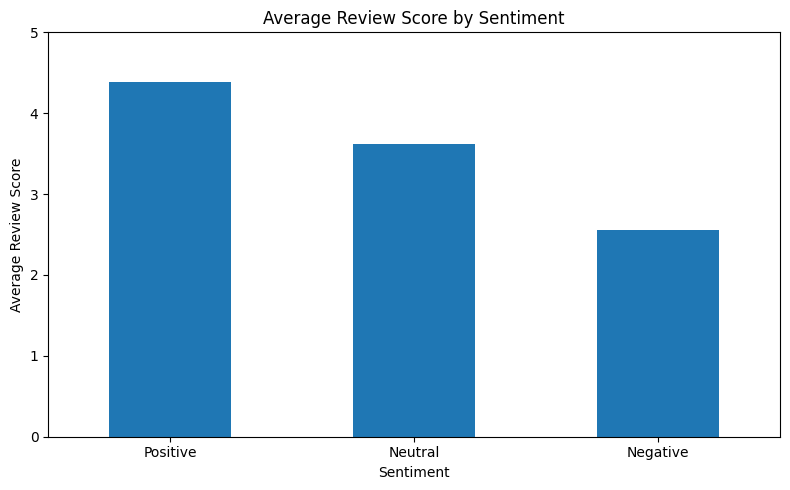

In [ ]:
plt.figure(figsize=(8, 5))

sentiment_score.plot(
    kind="bar",
    title="Average Review Score by Sentiment"
)

plt.xlabel("Sentiment")
plt.ylabel("Average Review Score")
plt.ylim(0, 5)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 10. Word Cloud Analysis

A word cloud is generated to identify frequently occurring words in customer reviews. Larger words represent words that appear more frequently in the review text.

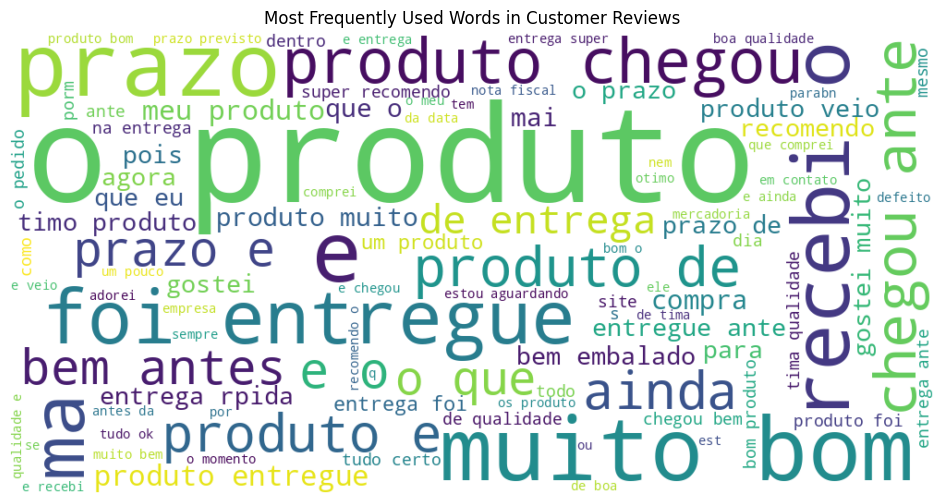

In [ ]:
all_reviews = " ".join(reviews_clean["clean_text"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white",
    max_words=100
).generate(all_reviews)

# Display the word cloud
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequently Used Words in Customer Reviews")
plt.show()

## 11. Key Insights

The sentiment analysis results are summarized to identify important patterns in customer feedback.

In [ ]:
# ---------------------------------------------------------
# KEY INSIGHTS
# ---------------------------------------------------------

# Total number of reviews analyzed
total_reviews = len(reviews_clean)

# Find the most common sentiment
most_common_sentiment = sentiment_counts.idxmax()
most_common_count = sentiment_counts.max()

# Calculate percentage of the most common sentiment
most_common_percentage = (most_common_count / total_reviews) * 100

print("Key Insights:")
print("-" * 50)
print(f"Total reviews analyzed: {total_reviews:,}")
print(
    f"Most common sentiment: {most_common_sentiment} "
    f"({most_common_count:,} reviews, {most_common_percentage:.2f}%)"
)
print(
    f"Positive reviews: {sentiment_counts.get('Positive', 0):,}"
)
print(
    f"Negative reviews: {sentiment_counts.get('Negative', 0):,}"
)
print(
    f"Neutral reviews: {sentiment_counts.get('Neutral', 0):,}"
)

Key Insights:
--------------------------------------------------
Total reviews analyzed: 40,791
Most common sentiment: Neutral (37,320 reviews, 91.49%)
Positive reviews: 2,973
Negative reviews: 498
Neutral reviews: 37,320


### Key Findings

- A large number of customer reviews were available for sentiment analysis after removing empty review texts.
- Neutral sentiment represents the largest category in the analyzed dataset.
- Positive reviews are substantially more common than negative reviews.
- Negative reviews represent the smallest sentiment category.
- The word cloud shows frequently used terms related to products, delivery, arrival time, and customer experience.
- The numerical review scores can be used alongside text sentiment to understand customer satisfaction.
- Since many reviews are written in Portuguese, the TextBlob-based sentiment classification may classify some reviews as Neutral. Therefore, the results should be interpreted as a demonstration of the NLP workflow rather than a perfect representation of customer sentiment.

## 12. Conclusion

The sentiment analysis task demonstrated how Natural Language Processing techniques can be applied to e-commerce customer reviews. The review text was cleaned and preprocessed before applying TextBlob-based sentiment classification.

The analysis classified customer reviews into Positive, Negative, and Neutral categories and presented the results using visualizations such as a sentiment distribution chart and a word cloud. The comparison with numerical review scores also provided an additional perspective on customer feedback.

Overall, the project demonstrates the use of Python, NLP preprocessing, sentiment classification, data analysis, and visualization to extract useful information from customer review data.

## 13. Limitations

- The review dataset contains a large amount of Portuguese text.
- TextBlob is primarily designed for English sentiment analysis, which can reduce the accuracy of sentiment classification for Portuguese reviews.
- Many reviews may therefore be classified as Neutral even when they contain positive or negative meaning.
- A multilingual or Portuguese-specific sentiment model could provide more accurate results in a production-level system.